# AG-HYPOPT · Trial 13

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

[Twelve trials recorded; best is trial 12 (0.0150). Sequence: 01 0.0981, 02 0.0246, 03 0.0477, 04 0.0262, 05 0.0196, 06 0.0329, 07 0.0205, 08 0.0294, 09 0.0182, 10 0.0301, 11 0.0174, 12 0.0150. Trials 05/07/08/09/10/11/12 are the same plateau point (lr_mu ~27, sigma_ref ~6.1-6.3, lr_gamma ~0.42, gamma_anneal ~0.39-0.43); their objectives span 0.0150-0.0301, dominated by Trans05 gamma noise, and the best has crept down (0.0196 -> 0.0182 -> 0.0174 -> 0.0150) as more runs land well - trial 12 also had the lowest sigma_ref (6.09) and the best gamma (9.6%). mu sits at 14.4-17.2%. No hyperparameter value outside this plateau region has come close; lr_mu peaks near 27 and sigma_ref is monotone (smaller better). We are in the TPE phase (13th trial).]


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_13'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 20    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (12/5 trials)
ID |     ei | params
 1 | 3.6354 | {"gamma_anneal": 0.35123894808858264, "lr_gamma": 0.4189876350563394, "lr_mu": 28.661644511151582, "sigma_ref": 6.1376931084170785}
 2 | 3.9992 | {"gamma_anneal": 0.39723760904609756, "lr_gamma": 0.41840793886197497, "lr_mu": 15.957001182585536, "sigma_ref": 6.160168056064383}
 3 | 3.9745 | {"gamma_anneal": 0.3914920505716792, "lr_gamma": 0.8213489248006949, "lr_mu": 27.07658788611711, "sigma_ref": 6.178323753765404}
 4 | 3.9817 | {"gamma_anneal": 0.4492332392750784, "lr_gamma": 0.41945919749189237, "lr_mu": 18.75570972458432, "sigma_ref": 6.142872279257885}
 5 | 3.9836 | {"gamma_anneal": 0.4039461581502638, "lr_gamma": 0.41803745470452325, "lr_mu": 28.961707985316178, "sigma_ref": 6.103205998521299}
 6 | 3.9789 | {"gamma_anneal": 0.39593166421924686, "lr_gamma": 0.6836639104298754, "lr_mu": 26.897716652660524, "sigma_ref": 6.117002913397118}
 7 | 3.9981 | {"gamma_anneal": 0.3929061112804068, "lr_gamma": 0.417889685871882

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

[Best is trial 12 (0.0150), the plateau config with the lowest sigma_ref encountered (6.09). The TPE batch again proposes the plateau; the top-ei draw is #8 (ei 3.9999: lr_mu 27.07, sigma_ref 6.127, lr_gamma 0.419, gamma_anneal 0.426), essentially trial 12 with sigma_ref a touch higher, and the other high-ei candidates either drop lr_mu (#2 15.96, #7 18.99, both in the known-poor low-lr_mu region) or raise lr_gamma (#6 0.68). Since sigma_ref has been monotone and trial 12's low-sigma_ref point is best, the sensible choice is the top-ei draw that stays on the plateau, candidate 8. It is the model's joint-best and repeats the winning configuration, which is what the campaign must do to confirm the floor given that single-run Trans05 noise exceeds the tunable effects. I choose candidate 8.]


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 8               # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'gamma_anneal': 0.42584174403884456, 'lr_gamma': 0.4192244113569571, 'lr_mu': 27.07378447528217, 'sigma_ref': 6.127088678533054}
Running  1nW Trans05 ... 

μ 9.39 -> 6.90 | γ 8.5 -> 4.22 | NLL 1.28


Running  1nW Trans20 ... 

μ 17.32 -> 15.81 | γ 8.5 -> 7.87 | NLL 2.80


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 99.82 | γ 14.1 -> 13.91 | NLL 3.36


Running 3nW Trans100 ... 

μ 175.71 -> 157.05 | γ 14.1 -> 13.87 | NLL 2.93



Total: 7.0 min


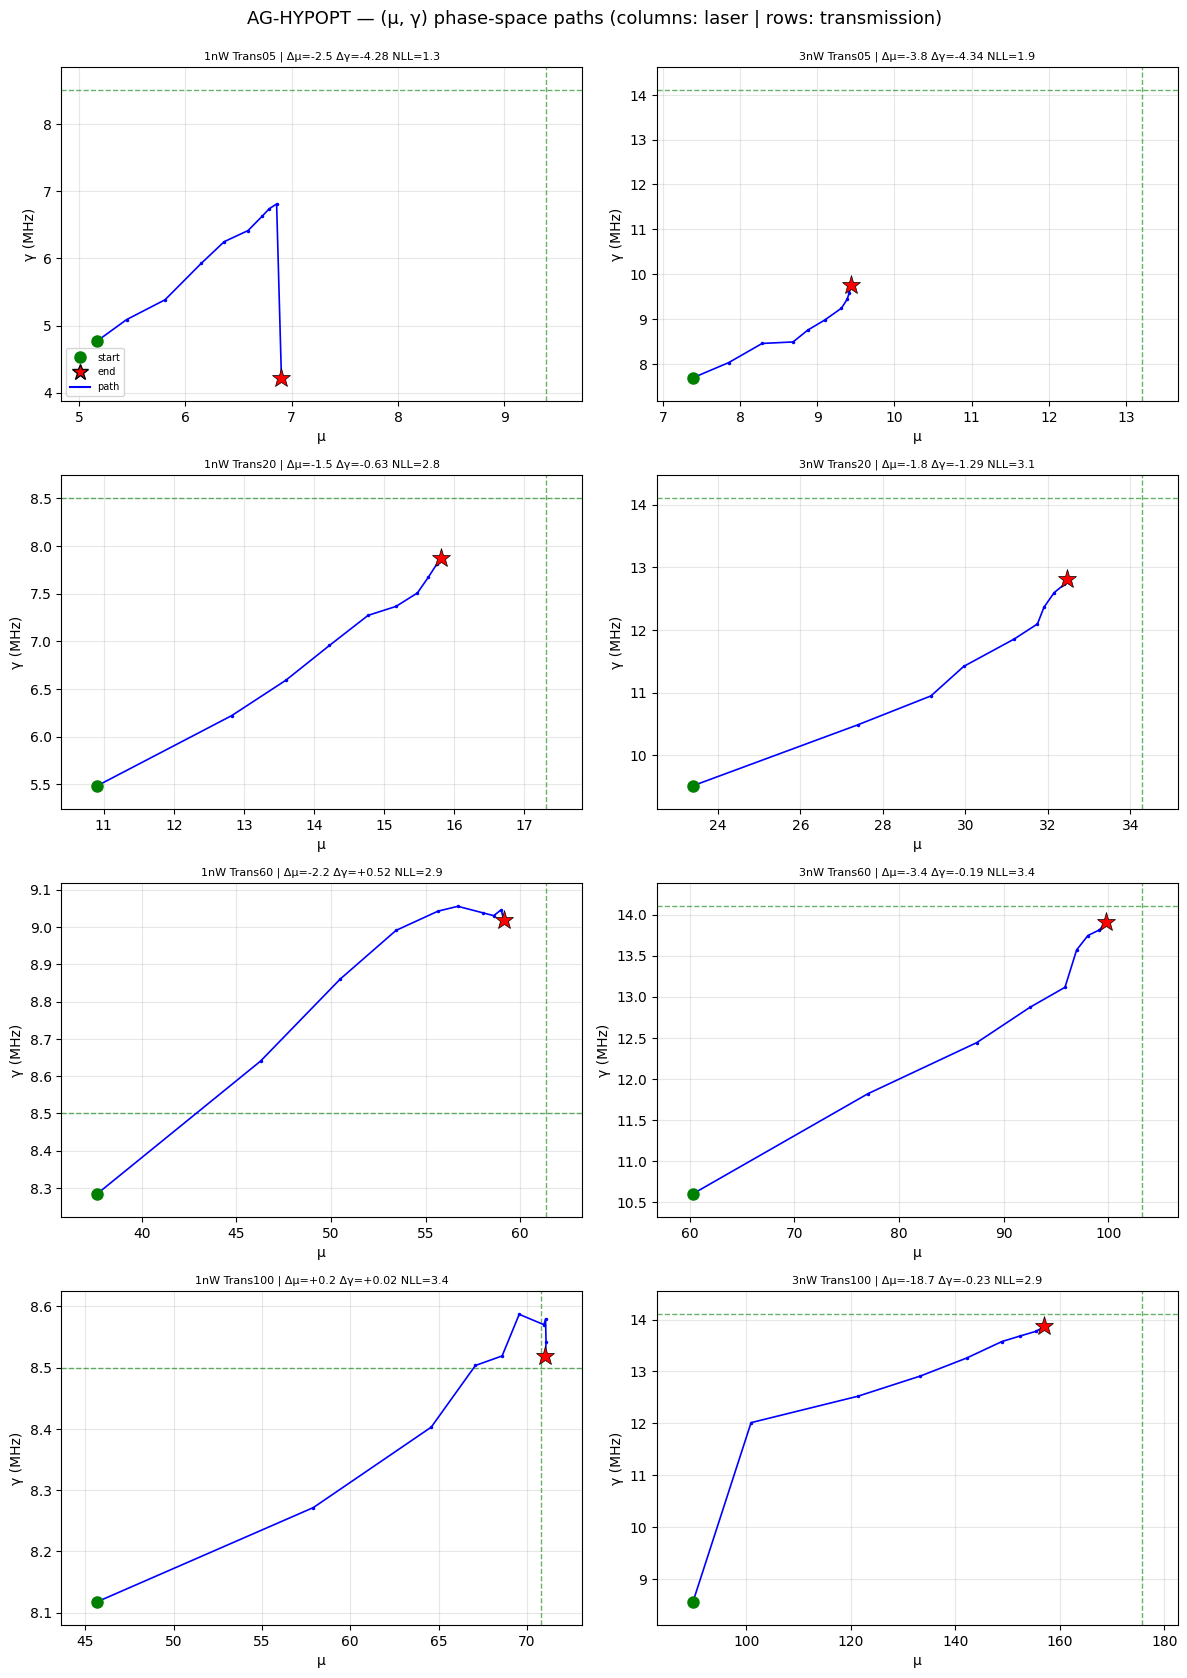

trial finished in 7.0 min
objective = 0.0339 ± 0.0167
exp           μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05     9.39    6.90   -26.5 |     8.50    4.22   -50.3
1nW Trans20    17.32   15.81    -8.7 |     8.50    7.87    -7.4
1nW Trans60    61.37   59.13    -3.7 |     8.50    9.02    +6.1
1nW Trans100   70.82   71.03    +0.3 |     8.50    8.52    +0.2
3nW Trans05    13.20    9.43   -28.6 |    14.10    9.76   -30.8
3nW Trans20    34.28   32.47    -5.3 |    14.10   12.81    -9.2
3nW Trans60   103.20   99.82    -3.3 |    14.10   13.91    -1.4
3nW Trans100  175.71  157.05   -10.6 |    14.10   13.87    -1.6

μ: RMSE 6.987 (rel 14.8%, bias -4.206) | γ: RMSE 2.224 (rel 21.4%, bias -1.302)


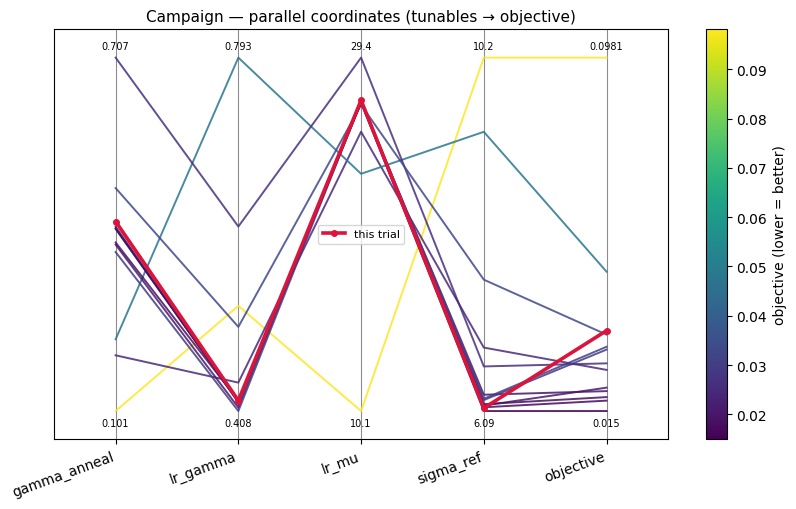

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 13 (sigma_ref 6.127, lr_mu 27.07, lr_gamma 0.419, gamma_anneal 0.426), the top-ei plateau draw, ran 7.0 min and scored 0.0339 +/- 0.0167, the worst of the recent plateau runs, entirely because of one scan: 1nW Trans05 gamma_fit 4.22 vs true 8.5 (-50.3%), an extreme low-count failure. mu held at 14.8% (the floor), while gamma jumped to 21.4%. Seven runs of the plateau config (trials 05/07/08/09/10/11/12/13) now span 0.0150-0.0339; mu is tightly at 14.4-17.2% but gamma ranges 9.6-21.4%, and the whole spread traces to the Trans05 points (1nW or 3nW) where a few fits collapse. So the plateau optimum is settled and the objective is dictated by whether the low-count Trans05 scans behave; trial 12 (0.0150) remains best.

**Summary:** Trial 13 (sigma_ref 6.127, lr_mu 27.07, lr_gamma 0.419, gamma_anneal 0.426) scored 0.0339 +/- 0.0167, the worst recent plateau run, purely from a 1nW Trans05 gamma collapse (-50.3%); mu held at 14.8% and gamma rose to 21.4%.
**Key insight:** The plateau config gives mu 14.4-17.2% but gamma 9.6-21.4% depending on whether the low-count Trans05 scans collapse; the objective variance is a single-scan effect, not a tunable one.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
[Notes for Anuar: none this trial.]


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'Trial 13 (sigma_ref 6.127, lr_mu 27.07, lr_gamma 0.419, gamma_anneal 0.426) scored 0.0339 +/- 0.0167, the worst recent plateau run, purely from a 1nW Trans05 gamma collapse (-50.3%); mu held at 14.8% and gamma rose to 21.4%.'
KEY_INSIGHT = 'The plateau config gives mu 14.4-17.2% but gamma 9.6-21.4% depending on whether the low-count Trans05 scans collapse; the objective variance is a single-scan effect, not a tunable one.'


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_13 | current best: trial_12


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_14.ipynb. Open it and follow its cells from the top.
